<a href="https://colab.research.google.com/github/1k4r15/house-price-linear-regression/blob/main/notebooks/01_regresion_lineal_gradiente_vs_ols.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Precios de Vivienda con Regresión Lineal: Descenso de Gradientes vs. OLS

**Objetivo:** implementar regresión lineal desde cero con descenso de gradientes (NumPy puro), y validar la implementación comparándola contra la solución analítica (Mínimos Cuadrados Ordinarios) y contra `sklearn.LinearRegression`.

**Dataset:** [USA Housing Dataset](https://github.com/huzaifsayed/Linear-Regression-Model-for-House-Price-Prediction/blob/master/USA_Housing.csv) — sintético, 5,000 filas.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/1k4r15/house-price-linear-regression/main/data/raw/USA_Housing.csv"
df = pd.read_csv(url)

df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


## Exploración de Datos (EDA)

Reviso primero la estructura del dataset: tipos de dato, valores nulos y estadísticas básicas.

In [2]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Avg. Area Number of Bedrooms,0
Area Population,0
Price,0
Address,0


### Resultado inicial

Sin valores nulos en ninguna de las 7 columnas. 6 son numéricas y `Address` es texto (se descartará, no aporta información utilizable en este formato).

### Relación entre variables

Antes de modelar, reviso cómo se distribuye el precio y cómo se correlaciona cada feature con él — esto ayuda a anticipar qué variables van a pesar más en el modelo.

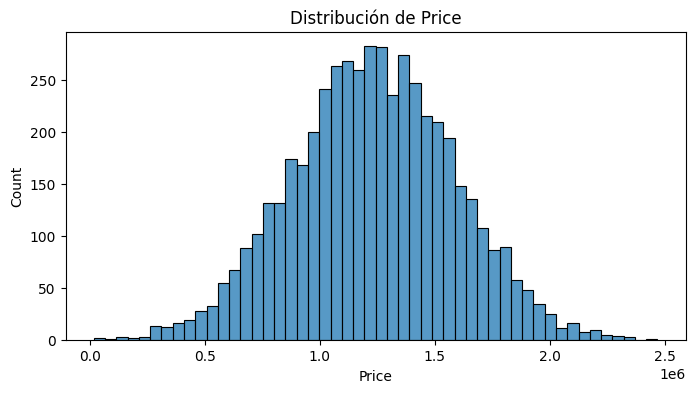

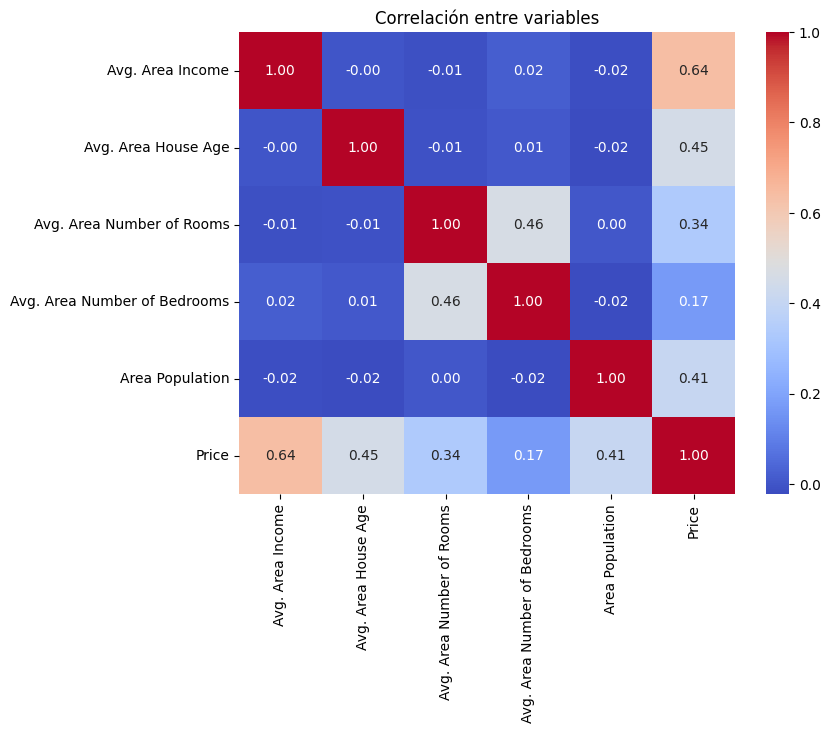

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución del precio (variable objetivo)
plt.figure(figsize=(8,4))
sns.histplot(df['Price'], bins=50)
plt.title('Distribución de Price')
plt.show()

# Matriz de correlación entre las variables numéricas
plt.figure(figsize=(8,6))
corr = df.drop(columns=['Address']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación entre variables')
plt.show()

### Interpretación de la exploración

- `Price` tiene una distribución **simétrica** (a diferencia del sesgo que vimos con los autos en el Bloque 1) — no va a hacer falta ninguna transformación logarítmica acá.
- `Avg. Area Income` es la variable más correlacionada con el precio (0.64), seguida de `House Age` (0.45), `Population` (0.41) y `Rooms` (0.34). `Bedrooms` es la más débil (0.17).
- Hay multicolinealidad moderada entre `Rooms` y `Bedrooms` (0.46) — no lo suficientemente alta como para eliminar alguna.

## Preparación para el Modelado

Separo `X` (features) de `y` (target), y luego entrenamiento de prueba, estandarizando solo con los datos de entrenamiento para evitar fuga de datos.

In [4]:
X = df.drop(columns=['Price', 'Address'])
y = df['Price']

print(X.shape, y.shape)
print(X.columns.tolist())

(5000, 5) (5000,)
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit solo con train
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, "| Test:", X_test_scaled.shape)

Train: (4000, 5) | Test: (1000, 5)


## Modelado: Descenso de Gradientes (implementación desde cero)

Implemento el algoritmo manualmente con NumPy: en cada iteración, calculo las predicciones como `X·w`, el error respecto al precio real, el gradiente del error cuadrático medio, y actualizo los pesos moviéndome en la dirección opuesta al gradiente. El objetivo es demostrar que entiendo la matemática del algoritmo, no solo cómo llamar una función de sklearn.

In [6]:
import numpy as np

def gradient_descent(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    X_b = np.c_[np.ones((m, 1)), X]   # agrega columna de 1s -> esa columna multiplica al w0 (intercepto)
    w = np.zeros(n + 1)               # empezamos con todos los pesos en cero
    cost_history = []

    for epoch in range(epochs):
        y_pred = X_b @ w                       # ŷ = X·w (el "modelo" en una sola operación matricial)
        error = y_pred - y
        gradient = (2/m) * (X_b.T @ error)     # derivada del costo (MSE) respecto a cada peso
        w = w - lr * gradient                   # paso cuesta abajo, en dirección opuesta al gradiente
        cost_history.append(np.mean(error ** 2))

    return w, cost_history

w_gd, cost_history = gradient_descent(X_train_scaled, y_train.values, lr=0.1, epochs=1000)

print("Pesos encontrados (w0=intercepto, luego uno por feature):")
print(w_gd)
print("\nCosto inicial:", cost_history[0])
print("Costo final:", cost_history[-1])

Pesos encontrados (w0=intercepto, luego uno por feature):
[1229576.99256009  231741.87665217  163580.77656614  120724.77138745
    2992.44913541  152235.90009699]

Costo inicial: 1636904225313.5107
Costo final: 10256318867.482723


### Resultado del entrenamiento

El costo cae de forma muy pronunciada entre la iteración inicial y la final — señal de que el algoritmo efectivamente se está acercando al mínimo de la función de costo. Reviso la curva de convergencia completa para confirmarlo visualmente.

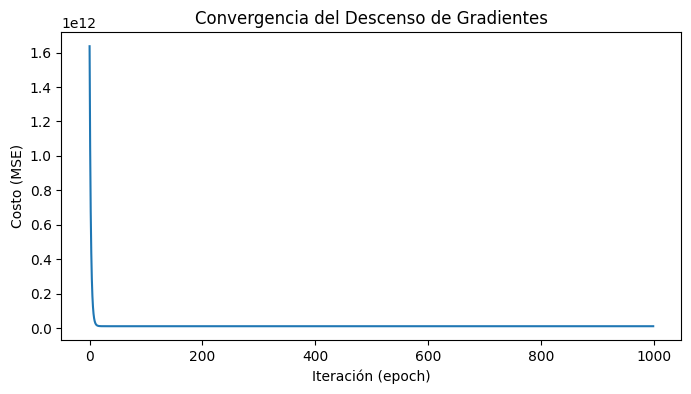

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(cost_history)
plt.xlabel('Iteración (epoch)')
plt.ylabel('Costo (MSE)')
plt.title('Convergencia del Descenso de Gradientes')
plt.show()

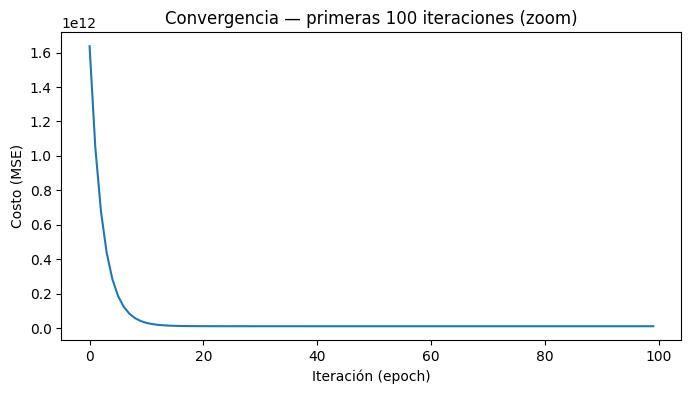

In [8]:
plt.figure(figsize=(8,4))
plt.plot(cost_history[:100])
plt.xlabel('Iteración (epoch)')
plt.ylabel('Costo (MSE)')
plt.title('Convergencia — primeras 100 iteraciones (zoom)')
plt.show()

### Interpretación de la convergencia

La curva tiene la forma esperada para una función de costo convexa con features normalizadas: cae en picada y se aplana casi de inmediato (dentro de las primeras ~15-20 iteraciones de las 1000 totales). Esto confirma lo que vimos en la teoría: con una "superficie de costo" esférica, el gradiente apunta directo al mínimo sin zigzaguear.

## Validación: Comparación contra OLS y Scikit-learn

Para confirmar que mi implementación manual llegó al resultado correcto, la comparo contra la solución analítica (ecuación normal) y contra la librería estándar.

In [9]:
def ols_normal_equation(X, y):
    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]
    return np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

w_ols = ols_normal_equation(X_train_scaled, y_train.values)
print("Pesos OLS (ecuación normal):")
print(w_ols)

Pesos OLS (ecuación normal):
[1229576.99256009  231741.87665217  163580.77656614  120724.77138745
    2992.44913541  152235.90009699]


In [10]:
from sklearn.linear_model import LinearRegression

lr_sklearn = LinearRegression()
lr_sklearn.fit(X_train_scaled, y_train)

print("Intercepto sklearn:", lr_sklearn.intercept_)
print("Coeficientes sklearn:", lr_sklearn.coef_)

Intercepto sklearn: 1229576.9925600903
Coeficientes sklearn: [231741.87665217 163580.77656614 120724.77138745   2992.44913541
 152235.90009699]


In [11]:
comparacion_pesos = pd.DataFrame({
    'Feature': ['Intercepto'] + X.columns.tolist(),
    'Gradiente Descendente': w_gd,
    'OLS (ecuación normal)': w_ols,
    'Sklearn': [lr_sklearn.intercept_] + list(lr_sklearn.coef_)
})
print(comparacion_pesos)

                        Feature  Gradiente Descendente  OLS (ecuación normal)  \
0                    Intercepto           1.229577e+06           1.229577e+06   
1              Avg. Area Income           2.317419e+05           2.317419e+05   
2           Avg. Area House Age           1.635808e+05           1.635808e+05   
3     Avg. Area Number of Rooms           1.207248e+05           1.207248e+05   
4  Avg. Area Number of Bedrooms           2.992449e+03           2.992449e+03   
5               Area Population           1.522359e+05           1.522359e+05   

        Sklearn  
0  1.229577e+06  
1  2.317419e+05  
2  1.635808e+05  
3  1.207248e+05  
4  2.992449e+03  
5  1.522359e+05  


### Resultado de la validación

Los tres métodos —descenso de gradientes, OLS y sklearn— convergen al **mismo resultado exacto**, coincidiendo hasta el segundo decimal en cada peso. Esto confirma que mi implementación manual encontró el mismo mínimo que los métodos analíticos/profesionales.

Como las features están normalizadas, los pesos son comparables entre sí: `Avg. Area Income` tiene el coeficiente más grande, consistente con ser la variable más correlacionada con el precio.

## Evaluación del Modelo en el Set de Prueba

Evalúo las predicciones sobre el 20% de datos que el modelo nunca vio durante el entrenamiento.

In [12]:
def predict(X, w):
    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]
    return X_b @ w

y_pred_test = predict(X_test_scaled, w_gd)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print(f"MAE:  {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²:   {r2:.3f}")

MAE:  80,879
RMSE: 100,444
R²:   0.918


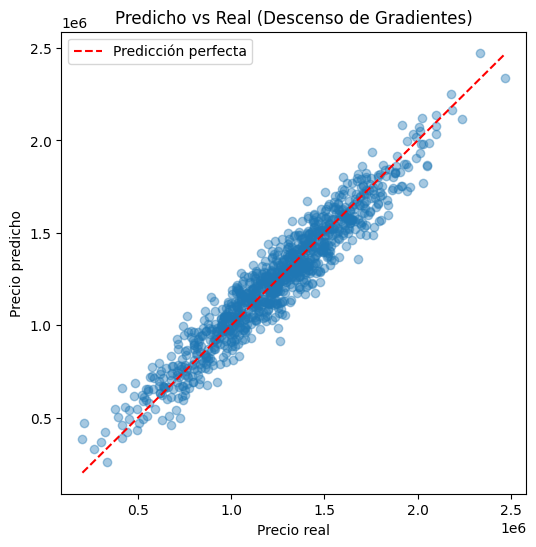

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Predicción perfecta')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Predicho vs Real (Descenso de Gradientes)')
plt.legend()
plt.show()

In [14]:
print("Precio promedio:", f"{y.mean():,.0f}")
print("MAE como % del precio promedio:", f"{mae / y.mean() * 100:.1f}%")

Precio promedio: 1,232,073
MAE como % del precio promedio: 6.6%


## Conclusiones

- La implementación manual de descenso de gradientes converge exactamente al mismo resultado que OLS y sklearn — confirma comprensión del algoritmo, no solo su uso.
- El modelo alcanza R² = 0.918 y un MAE de apenas ~6.6% del precio promedio, sin necesidad de ningún tuning de hiperparámetros (a diferencia de KNN, la regresión lineal encuentra el óptimo matemático de una sola vez).
- A diferencia del proyecto de autos (Bloque 1), no hay subestimación sistemática en ningún rango de precio — la diferencia clave es que acá la relación entre features y precio es genuinamente lineal, mientras que en KNN el problema era escasez de datos en ciertas zonas.
- `Avg. Area Income` es, por lejos, la variable con mayor peso en la predicción final, consistente con el análisis de correlación inicial.